In [5]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid',palette='muted')
plt.rcParams['figure.dpi']=110

In [6]:
credit=pd.read_csv("creditcard.csv")
credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
print("Credit :",credit.columns)

Credit : Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [12]:
print("Credit :",credit.shape)
print(credit.describe())

Credit : (284807, 31)
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00 

In [16]:
data = credit.dropna()
data.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

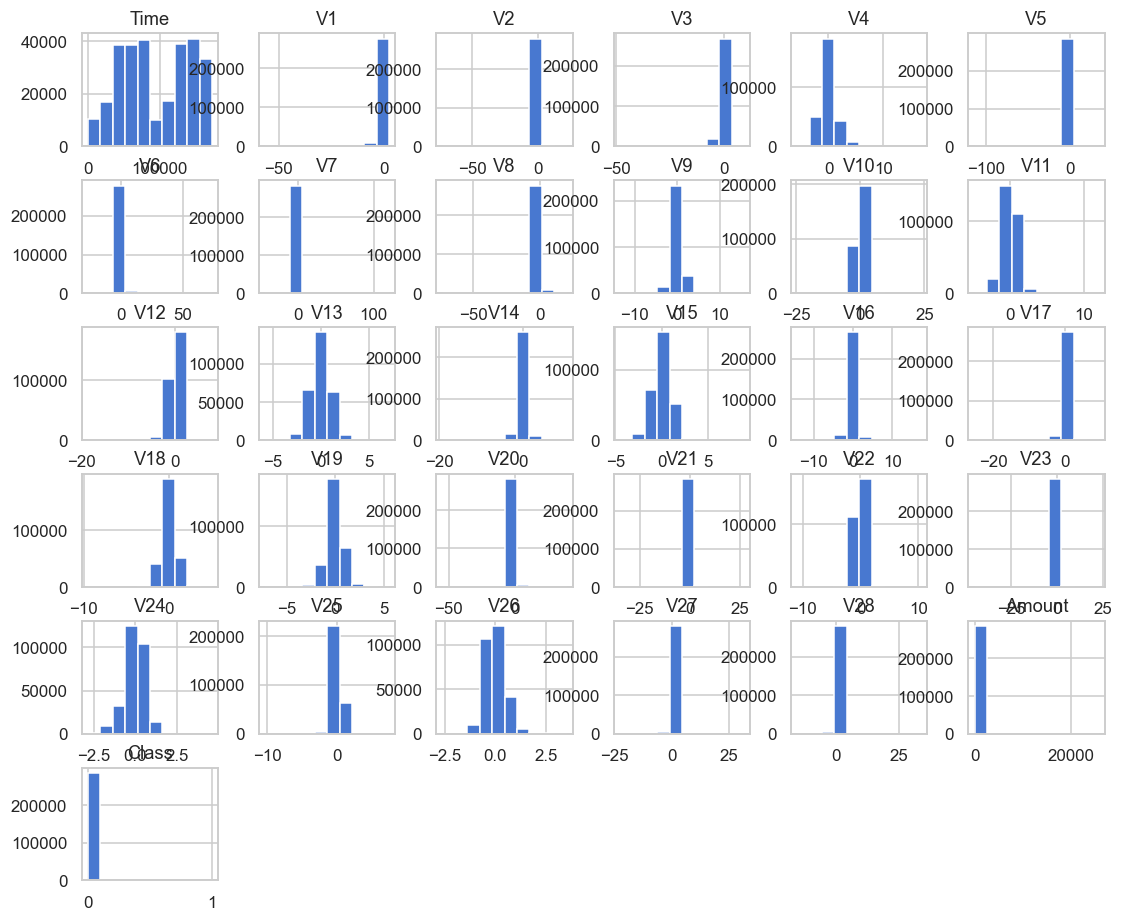

In [18]:
data.hist(figsize=(12,10))
plt.show()

In [20]:
fraud=(data['Class']==1).sum()
legitimate=(data['Class']==0).sum()
print("Fraud cases:",fraud)
print("Legitimate cases:",legitimate)

Fraud cases: 492
Legitimate cases: 284315


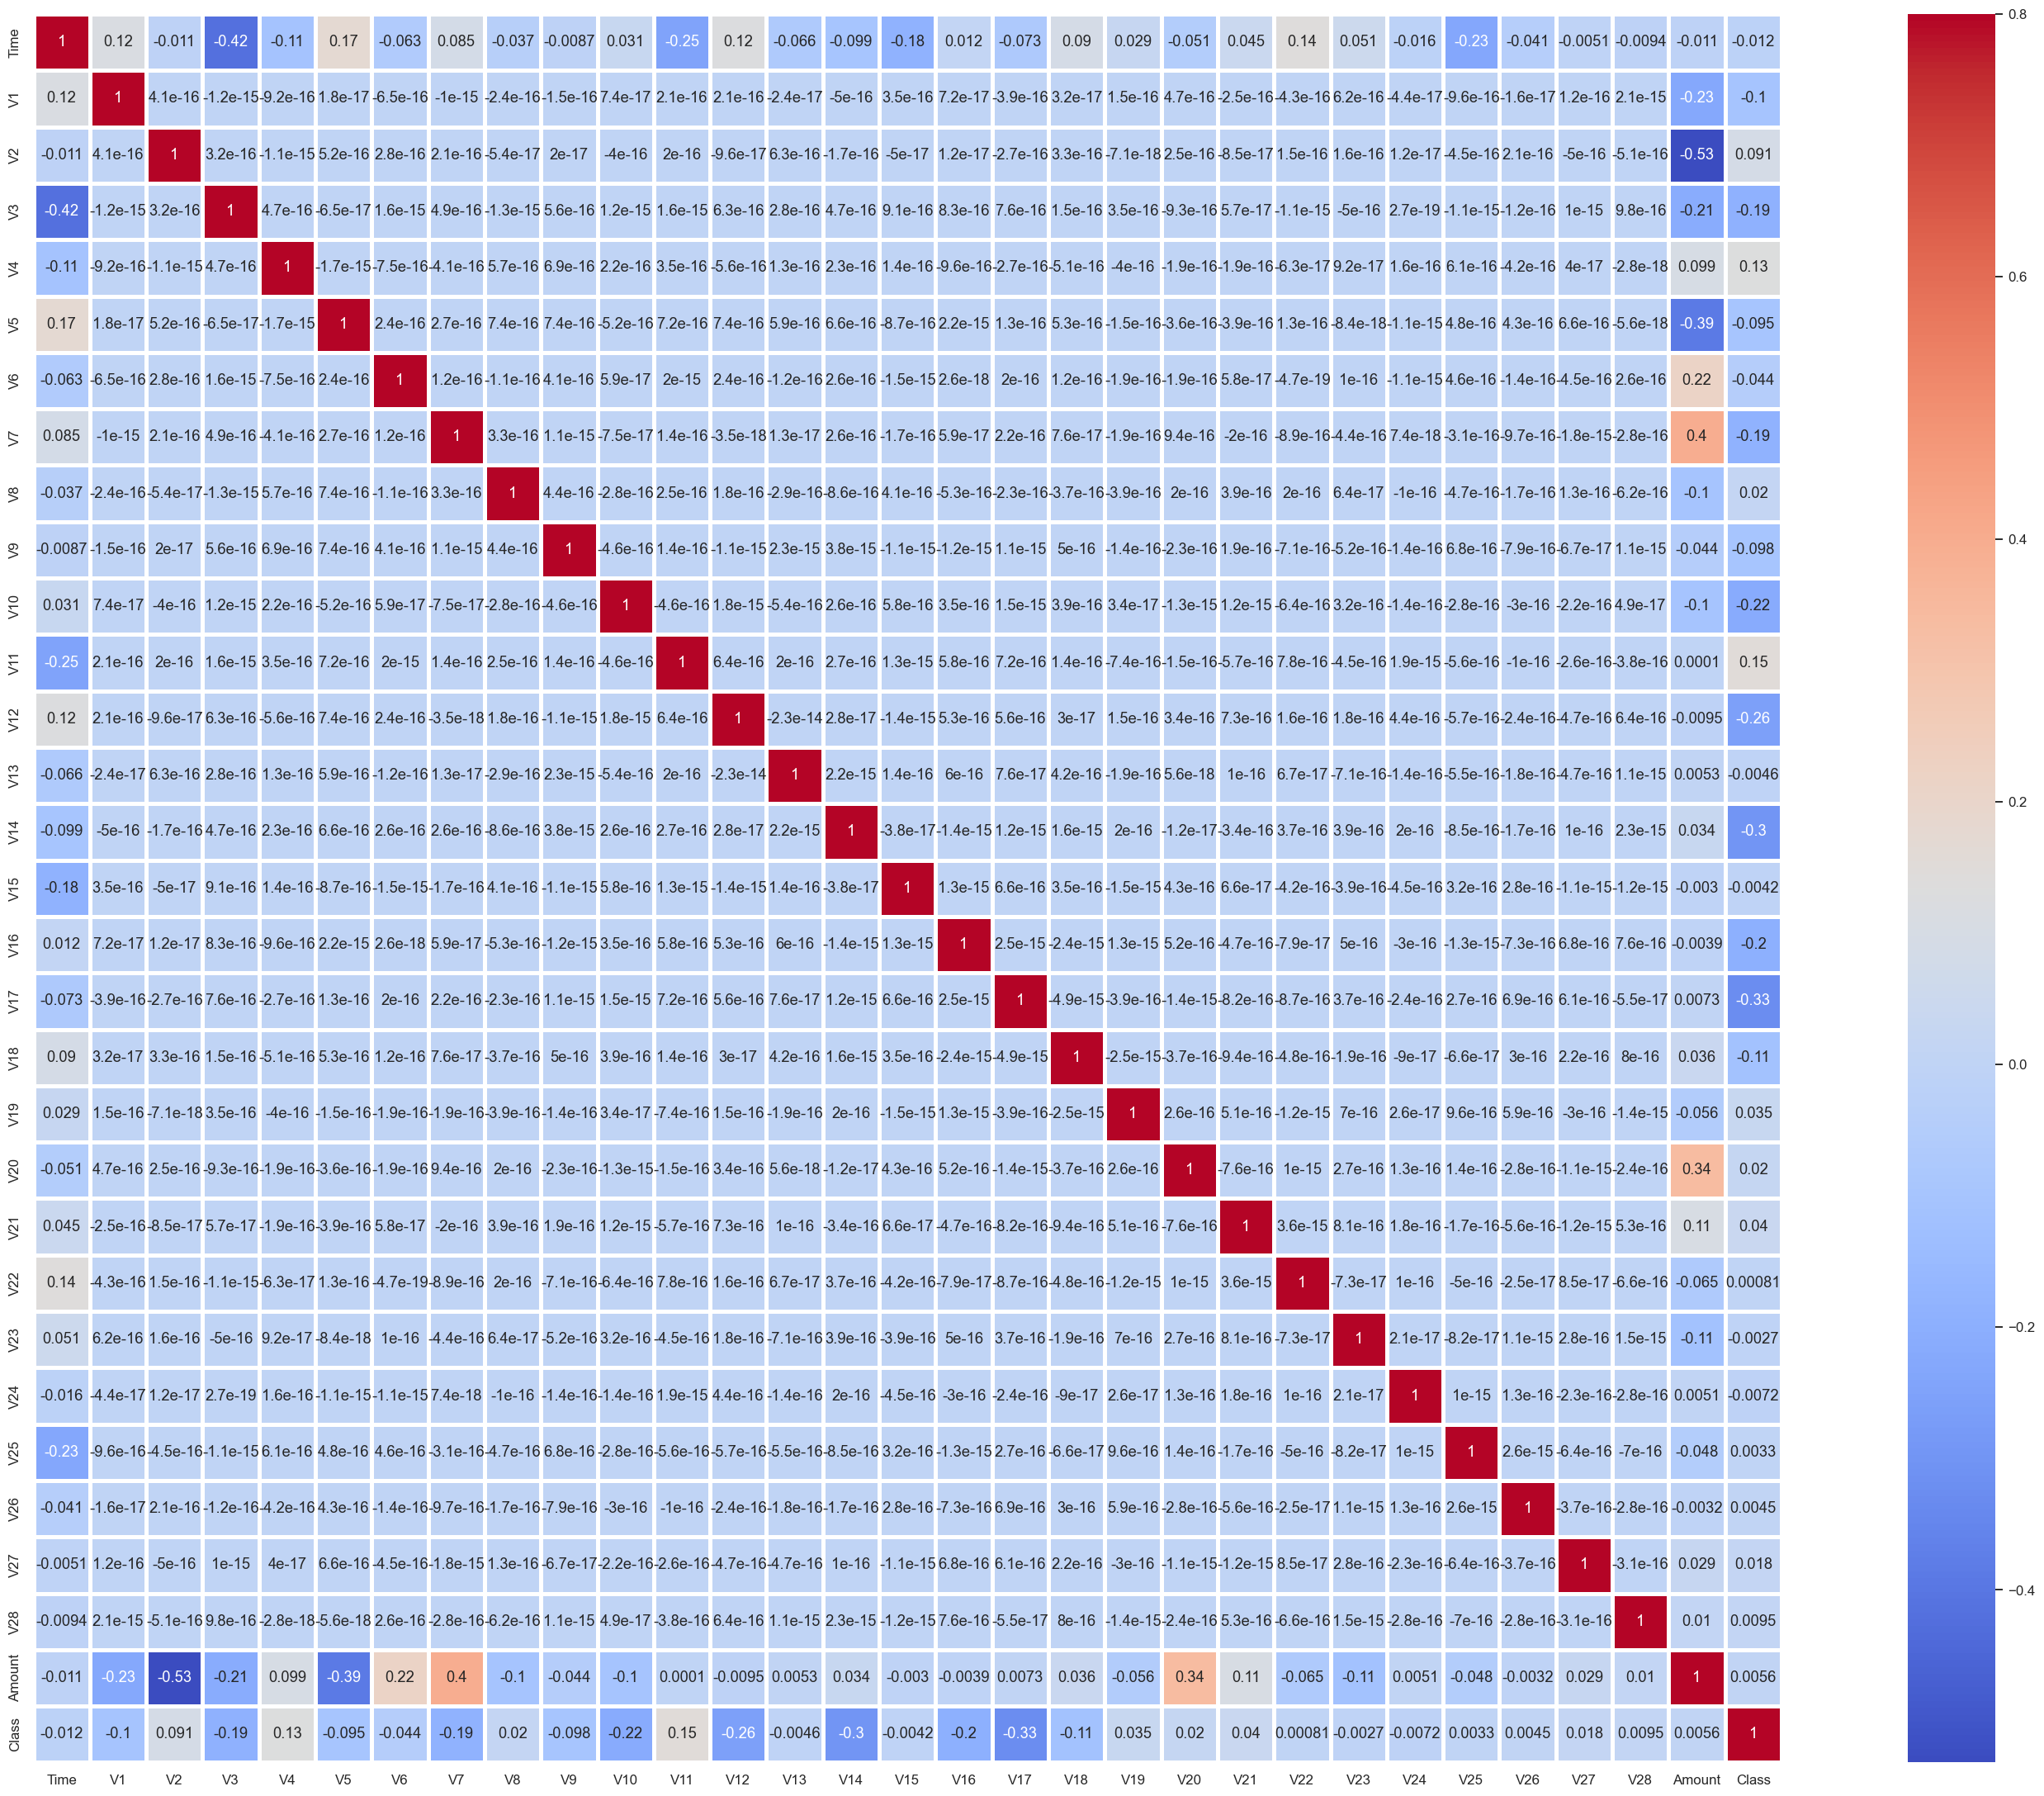

In [23]:
corrmat = data.corr()
fig = plt.figure(figsize=(36, 25))
sns.heatmap(corrmat, vmax=.8, square=True, annot=True, cmap='coolwarm', linewidth=2)
plt.show()

In [30]:
columns = credit.columns.tolist()
print(columns)
target = 'Class'
X = data[columns]
Y = data[target] 
print("X.shape:",X.shape)
print("Y.shape:",Y.shape)

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
X.shape: (284807, 31)
Y.shape: (284807,)


In [46]:
from sklearn.model_selection import train_test_split
# Split into 80% train, 20% test
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [47]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", y_train.shape)
print("Y_test:", y_test.shape)

X_train: (227845, 31)
X_test: (56962, 31)
Y_train: (227845,)
Y_test: (56962,)


In [37]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)   # fit on train, transform train
X_test_sc  = sc.transform(X_test)        # transform test using train's parameters
print(X_test_sc.dtype)

float64


In [38]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
Y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,Y_pred)
print("Accuracy score:",accuracy)

Accuracy score: 1.0


In [49]:
dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled.fit(X_train_sc,y_train)
Y_pred_sc = dt_scaled.predict(X_test_sc)
accuracy_sc = accuracy_score(y_test,Y_pred_sc)
print("Accuracy Score(Scaled Data):",accuracy_sc)

Accuracy Score(Scaled Data): 1.0


In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=20, criterion='entropy', random_state=5)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print('Random Forest (raw):', accuracy_score(y_test, y_pred_rf))

Random Forest (raw): 1.0


In [54]:
rf_clf_sc = RandomForestClassifier(n_estimators=20, criterion='entropy', random_state=5)
rf_clf_sc.fit(X_train_sc, y_train)
y_pred_rf_sc = rf_clf_sc.predict(X_test_sc)
print('Random Forest (scaled):', accuracy_score(y_test, y_pred_rf_sc))

Random Forest (scaled): 1.0


In [55]:
from sklearn.ensemble import AdaBoostClassifier

abd_clf = AdaBoostClassifier(
    DecisionTreeClassifier(criterion='entropy', random_state=20),
    n_estimators=200, learning_rate=0.1, algorithm='SAMME', random_state=1)
abd_clf.fit(X_train, y_train)
y_pred_abd = abd_clf.predict(X_test)
print('AdaBoost (raw):', accuracy_score(y_test, y_pred_abd))

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost (raw): 1.0


In [56]:
abd_clf_sc = AdaBoostClassifier(
    DecisionTreeClassifier(criterion='entropy', random_state=20),
    n_estimators=200, learning_rate=0.1, algorithm='SAMME', random_state=1)
abd_clf_sc.fit(X_train_sc, y_train)
y_pred_abd_sc = abd_clf_sc.predict(X_test_sc)
print('AdaBoost (scaled):', accuracy_score(y_test, y_pred_abd_sc))

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost (scaled): 1.0


In [60]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 2.4 MB/s eta 0:00:29
    --------------------------------------- 1.0/69.5 MB 2.2 MB/s eta 0:00:31
    --------------------------------------- 1.3/69.5 MB 1.9 MB/s eta 0:00:37
    --------------------------------------- 1.3/69.5 MB 1.9 MB/s eta 0:00:37
    --------------------------------------- 1.6/69.5 MB 1.3 MB/s eta 0:00:52
    --------------------------------------- 1.6/69.5 MB 1.3 MB/s eta 0:00:52
   - -------------------------------------- 1.8/69.5 MB 1.1 MB/s eta 0:01:04
   - -------------------------------------- 1.8/69.5 MB 1.1 MB/s eta 0:01:04
   - -------------------------------------- 1.8/69.5 MB 1.1 MB/s eta 0:01:04
   - -------------------------------------- 2.1/69.5 MB 922.8 kB/s eta 0:01:14
   - -------------------------------------- 2.1/69.5 MB 922.8 kB/s eta 0:01:14
   - ----

In [67]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Train XGBClassifier on raw data
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, Y_train)

# Make predictions
Y_pred_xgb = xgb_model.predict(X_test)

# Print accuracy score
accuracy_xgb = accuracy_score(Y_test, Y_pred_xgb)
print("XGBoost Accuracy Score:", accuracy_xgb)

XGBoost Accuracy Score: 0.9999473333099259


In [69]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Train XGBClassifier on scaled data
xgb_scaled = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_scaled.fit(X_train_sc, Y_train)

# Make predictions
Y_pred_xgb_sc = xgb_scaled.predict(X_test_sc)

# Print accuracy score
accuracy_xgb_sc = accuracy_score(Y_test, Y_pred_xgb_sc)
print("XGBoost Accuracy Score (Scaled Data):", accuracy_xgb_sc)

XGBoost Accuracy Score (Scaled Data): 0.9999473333099259


In [73]:
from sklearn.metrics import confusion_matrix
y_pred_best = Y_pred_xgb_sc
cm = confusion_matrix(Y_test, y_pred_best)
print(cm)

[[56861     3]
 [    0    98]]


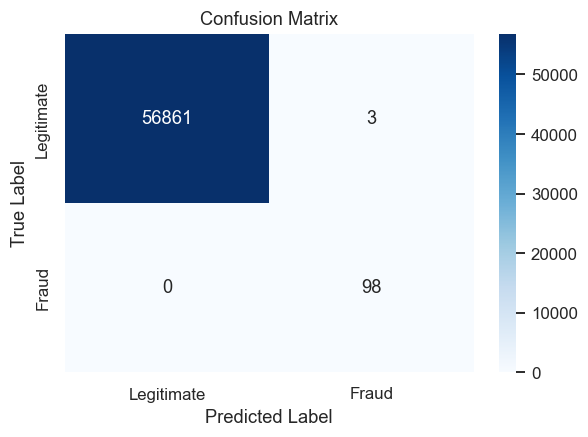

In [77]:
# Create confusion matrix
cm = confusion_matrix(Y_test, y_pred_best)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [80]:
report=classification_report(Y_test,y_pred_best)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      1.00      0.98        98

    accuracy                           1.00     56962
   macro avg       0.99      1.00      0.99     56962
weighted avg       1.00      1.00      1.00     56962



In [82]:
report = classification_report(Y_test, y_pred_best, output_dict=True)
fraud_recall = report['1']['recall']
print("Fraud Recall:", fraud_recall)

Fraud Recall: 1.0


In [83]:
!pip install imbalanced-learn

In [86]:
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

# Class distribution before SMOTE
print("Before SMOTE:")
print(Counter(Y_train))

# Apply SMOTE ONLY to training data
smote = SMOTE(random_state=42)
X_train_sm, Y_train_sm = smote.fit_resample(X_train, Y_train)

print("\nAfter SMOTE:")
print(Counter(Y_train_sm))

# Retrain best model
best_model_smote = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

best_model_smote.fit(X_train_sm, Y_train_sm)

# Predictions
y_pred_smote = best_model_smote.predict(X_test)

# Recall after SMOTE
report_smote = classification_report(
    Y_test,
    y_pred_smote,
    output_dict=True
)

fraud_recall_smote = report_smote['1']['recall']

print("\nRecall Before SMOTE:", fraud_recall)
print("Recall After SMOTE :", fraud_recall_smote)

Before SMOTE:
Counter({0: 227451, 1: 394})

After SMOTE:
Counter({0: 227451, 1: 227451})

Recall Before SMOTE: 1.0
Recall After SMOTE : 1.0


Average Precision (AP): 1.0


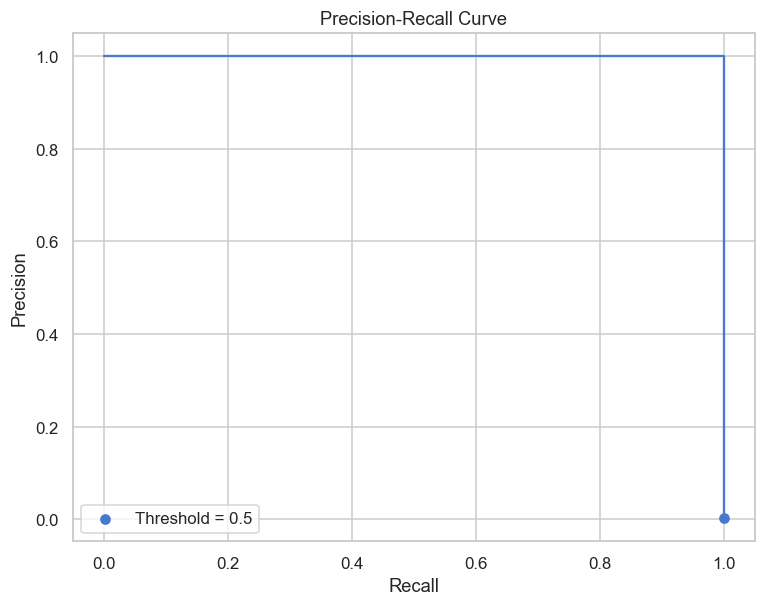

In [87]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Fraud probabilities
y_scores = best_model_smote.predict_proba(X_test)[:, 1]

# Precision-recall values
precision, recall, thresholds = precision_recall_curve(
    Y_test,
    y_scores
)

# Average Precision
ap = average_precision_score(Y_test, y_scores)

print("Average Precision (AP):", ap)

# Find point closest to threshold=0.5
idx = np.argmin(np.abs(thresholds - 0.5))

plt.figure(figsize=(8,6))
plt.plot(recall, precision)

plt.scatter(
    recall[idx],
    precision[idx],
    label="Threshold = 0.5"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [93]:
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

best_threshold = None
best_precision = 0
for t in np.arange(0.01, 1.0, 0.01):

    y_pred_t = (y_scores >= t).astype(int)

    p = precision_score(Y_test, y_pred_t, zero_division=0)
    r = recall_score(Y_test, y_pred_t)
    f1 = f1_score(Y_test, y_pred_t)

    if r >= 0.90 and p > best_precision:
        best_precision = p
        best_threshold = t
        best_recall = r
        best_f1 = f1

print("Chosen Threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)
print("F1 Score:", best_f1)

Chosen Threshold: 0.01
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
